In [4]:
!pip install muon mudata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [muon]3/4 [muon]


Note: you may need to restart the kernel to use updated packages.
Streaming 10x Genomics Multi-omics verification file...
■ File filtered_feature_bc_matrix.h5 from pbmc3k_multiome has been found at /Users/shaharyar/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5
■ Checksum is validated (md5) for filtered_feature_bc_matrix.h5
■ Loading filtered_feature_bc_matrix.h5...


/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/mudatasets/core.py:203: UserWarning: Dataset is in the 10X .h5 format and can't be loaded as backed.
  warn("Dataset is in the 10X .h5 format and can't be loaded as backed.")
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
Task was destroyed but it is pending!
task: <Task pending name='Task-233' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-234' coro=<_async_in_context.<locals>.preserve_context() running at /Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.

Added `interval` annotation for features from /Users/shaharyar/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5


/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/mudata/_core/mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/mudata/_core/mudata.py:613: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/mudata/_core/mudata.py:1322: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new b

Processing scRNA-seq & scATAC-seq modalities...


/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/muon/_atac/preproc.py:106: RuntimeWarning: divide by zero encountered in divide
  idf = np.asarray(adata.shape[0] / counts.sum(axis=0)).reshape(-1)
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 98319 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


Calculating Weighted Nearest Neighbor (WNN) joint Integration...


/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/mudata/_core/mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/mudata/_core/mudata.py:613: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/Users/shaharyar/Downloads/miniconda3/envs/scrna/lib/python3.10/site-packages/mudata/_core/mudata.py:1322: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new b

Rendering Joint Multiomidal UMAP Map...


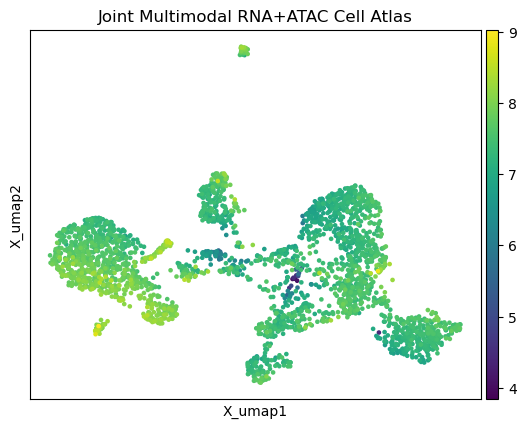

In [16]:
%pip install "mudatasets[muon]"

import scanpy as sc
import muon as mu
import mudatasets as mds

print("Streaming 10x Genomics Multi-omics verification file...")
mdata = mds.load("pbmc3k_multiome")

print("Processing scRNA-seq & scATAC-seq modalities...")
sc.pp.log1p(mdata['rna'])
sc.pp.calculate_qc_metrics(mdata['rna'], percent_top=None, log1p=True, inplace=True)
sc.pp.highly_variable_genes(mdata['rna'], min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.tl.pca(mdata['rna'], n_comps=40)
sc.pp.neighbors(mdata['rna'])

mu.atac.pp.tfidf(mdata['atac'], scale_factor=1e4)
mu.atac.tl.lsi(mdata['atac'], n_comps=40)
sc.pp.neighbors(mdata['atac'])

print("Calculating Weighted Nearest Neighbor (WNN) joint Integration...")
mdata.update()
mu.pp.neighbors(mdata, key_added='wnn')

print("Rendering Joint Multiomidal UMAP Map...")
mu.tl.umap(mdata, neighbors_key="wnn")
mu.pl.umap(mdata, color=['rna:log1p_total_counts'], title="Joint Multimodal RNA+ATAC Cell Atlas")
